# use pretrained resnet of ssl-wearable project
https://github.com/OxWearables/ssl-wearables/tree/main?tab=readme-ov-file

3-axes acceleration data only

input is (raw) acceleration data of umeneko2018, back=1

output is the reconstructed acc data

This work evaluates the performance of downstream task

In [16]:
import os

import matplotlib.pyplot as plt

# import pickle
import torch.optim as optim
# from utils import *
# from hubconf import load_weights
# from sslearning.models.accNet import Resnet
from umap import UMAP
import plotly.express as px
# from importlib.metadata import version, PackageNotFoundError

import pickle
import numpy as np
from tqdm import tqdm
import torch

from deepview.calculate_results.data.umineko_data import (
    read_umineko_data,
read_umineko_path,
extract_data_from_year_back,
label_dict,
get_accel_batch_data,
)

from deepview.calculate_results.models.utils import (
    Resnet,
load_weights,
MSEloss,
# torch,
AE_eval_time_series,
AE_train_time_series_resnet,
AE_train_time_series,
majority_value,
# np,
adjust_learning_rate,
# tqdm
sliding_window,
data_loader_umineko
)
from torch.utils.data import Dataset, DataLoader

In [3]:
back_label_path = r'D:\logbot-data\BioTaggerData\masterLabelsByOtsuka\animal_id.csv'
umi_root_path = r'D:\logbot-data\BioTaggerData\export\raw\umineko\v.1.0.0'
file_paths = read_umineko_path(umi_root_path)

year = '2018'
data_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko_%s.npy'%year
if os.path.exists(data_path):
    tmp = np.load(data_path, allow_pickle='TRUE').item()
    df_list = tmp['raw_data']
    df_clean_list = tmp['labeled_data']
    
selected_df, selected_clean_df = (
        extract_data_from_year_back(df_list, df_clean_list, 1))

selected_df['label_id'] = selected_df['label'].map(label_dict)
selected_clean_df['label_id'] = selected_clean_df['label'].map(label_dict)

# 将df_list没有标签的位置赋值-2，标记灰色，其他label正常标记。观察是否有label的标记能在不同灰色cluster中
# Replace NaN with -2 in column A
selected_df['label_id'] = selected_df['label_id'].fillna(-2)

device = 'cuda'
len_sw = 300
sensor_type = 'accel'
# train_loader = get_accel_batch_data(selected_df, 
#                                     len_sw, 
#                                     batch_size=512, 
#                                     device=device)

C:\Users\dell\AppData\Local\Temp\ipykernel_36288\3669579838.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['label_id'] = selected_df['label'].map(label_dict)
C:\Users\dell\AppData\Local\Temp\ipykernel_36288\3669579838.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_clean_df['label_id'] = selected_clean_df['label'].map(label_dict)
C:\Users\dell\AppData\Local\Temp\ipykernel_36288\3669579838.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [14]:
def standardization(input_array, mean, std, bias=0.0):
    return ((input_array - mean) / np.maximum(std, 10 ** -5)) + bias


In [20]:
selected_columns = ['acc_x', 'acc_y', 'acc_z',
                        'label_id']  # without timestamps

selected_np = selected_df[selected_columns].values
data_np = selected_np[:,:-1]
print(data_np.shape)
mean = np.mean(data_np, axis=0)
std = np.std(data_np, axis=0)
print("mean:",mean)
print("std:",std)
tmp_b_stand = standardization(data_np, mean, std)

selected_np[:,:-1] = tmp_b_stand
print(selected_np.shape)

tmp_b = sliding_window(selected_np, len_sw)
print(tmp_b.shape)

# concatenate list
data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
label_b = tmp_b[:, :, -1]  # [B, Len]

batch_size = 512
train_set_r = data_loader_umineko(data_b, label_b, device=device)
train_loader = DataLoader(train_set_r, batch_size=batch_size,
                          shuffle=False, drop_last=False)

(8404650, 3)
mean: [0.03523875 0.38986442 0.8461156 ]
std: [0.31962855 2.01546772 0.30623299]
(8404650, 4)
(56029, 300, 4)


In [4]:
# # 每一个文件为一个test loader
# test_filenames = df_ready.animal_tag.unique()
# test_loaders = []
# for f in test_filenames:
#     single_df = df_ready[df_ready['animal_tag']==f]
#     tmp_b = sliding_window(single_df[selected_columns], len_sw)
#     # concatenate list
#     data_b = tmp_b[:,:,:-1]  # [B, Len, dim-1]
#     label_b = tmp_b[:,:,-1]  # [B, Len]
#     test_set_r = data_loader_umineko(data_b, label_b, device=device)
#     test_loader = DataLoader(test_set_r, batch_size=batch_size,
#                            shuffle=False, drop_last=False)
#     test_loaders.append(test_loader)

## prepare model

In [5]:
set(list(label_dict.values()))

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14}

In [21]:

class_num = len(set(list(label_dict.values())))
# Example usage
model = Resnet(
        output_size=class_num,
        is_reconst=True,
        len_sw= len_sw,
        # is_simclr=True,
        # is_eva=True,
        resnet_version=1,
               )
model = model.to(device)
# dirname = os.path.dirname(__file__)
# checkpoint = os.path.join(
# os.getcwd(), "model_check_point", "mtl_best.mdl"
# )
checkpoint = r'D:\code\DeepView\deepview\calculate_results\model_check_point\mtl_best.mdl'
# print(checkpoint)

load_weights(
checkpoint, model, my_device=device, is_dist=True, name_start_idx=1
)


131 Weights loaded


D:\code\DeepView\deepview\calculate_results\models\utils.py:493: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_dict = torch.load(weight_path, map_location=my_devi

In [22]:
model

Resnet(
  (feature_extractor): Sequential(
    (layer1): Sequential(
      (0): Conv1d(3, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False, padding_mode=circular)
      (1): ResBlock(
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False, padding_mode=circular)
        (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False, padding_mode=circular)
        (relu): ReLU(inplace=True)
      )
      (2): ResBlock(
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False, padding_mode=circular)
        (conv2): Conv1d(6

In [23]:
criterion = MSEloss()
criterion = criterion.to(device)

learning_rate = 0.0001
optimizer = optim.Adam(
    model.parameters(), lr=learning_rate, amsgrad=True
)
optimizer = optim.Adam(
            model.parameters(), lr=learning_rate, amsgrad=True
        )
lambda1 = lambda epoch: 1.0**epoch
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda1)

#### visualize feature before finetuning

D:\Users\dell\anaconda3\envs\deepviewbackup\lib\site-packages\torch\nn\modules\module.py:1553: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


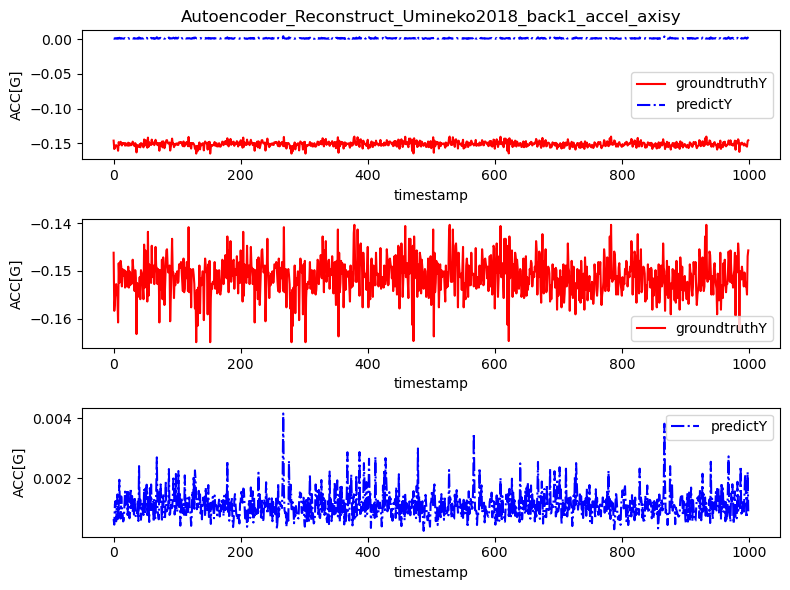

In [24]:
# reconstruction result
representation_list, sample_list, pred_list, label_list = \
            AE_eval_time_series(train_loader, model, device)

# tsne latent representation to shape=(2, len) PCA降维到形状为 (2, len)
repre_concat = np.concatenate(representation_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1)

sample_concat = np.concatenate(sample_list)
# sample_reshape = sample_concat.reshape(-1, 3)
sample_concat = sample_concat.transpose(0,2,1)
sample_reshape = sample_concat.reshape(-1, sample_concat.shape[-1])

pred_concat = np.concatenate(pred_list)
# pred_reshape = pred_concat.reshape(-1, 3)
pred_concat = pred_concat.transpose(0, 2, 1)
pred_reshape = pred_concat.reshape(-1, pred_concat.shape[-1])

label_concat = np.concatenate(label_list)
label_concat_vote = majority_value(label_concat)
# label_concat_vote.shape

start, end = 1000, 2000
fig, axes = plt.subplots(3, 1, figsize=(8, 6)) 
axes[0].plot(sample_reshape[start:end, 1], 'r', label='groundtruthY')
axes[0].plot(pred_reshape[start:end, 1], 'b-.', label='predictY')
axes[0].set_title('Autoencoder_Reconstruct_Umineko2018_back1_accel_axisy')
axes[0].set_xlabel('timestamp')
axes[0].set_ylabel('ACC[G]')
axes[0].legend()

axes[1].plot(sample_reshape[start:end, 1], 'r', label='groundtruthY')
# axes[1].plot(pred_reshape[10000:length, 1], 'b-.', label='predictY')
# axes[1].set_title('ResNet_SSL_pretrained_Reconstruct_Umineko2018_back1')
axes[1].set_xlabel('timestamp')
axes[1].set_ylabel('ACC[G]')
axes[1].legend()

# axes[2].plot(sample_reshape[10000:length, 1], 'r', label='groundtruthY')
axes[2].plot(pred_reshape[start:end, 1], 'b-.', label='predictY')
# axes[2].set_title('ResNet_SSL_pretrained_Reconstruct_Umineko2018_back1')
axes[2].set_xlabel('timestamp')
axes[2].set_ylabel('ACC[G]')
axes[2].legend()

# Adjust layout
plt.tight_layout()
# Show the figure
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_36288\1242004127.py:25: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.

D:\Users\dell\anaconda3\envs\deepviewbackup\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



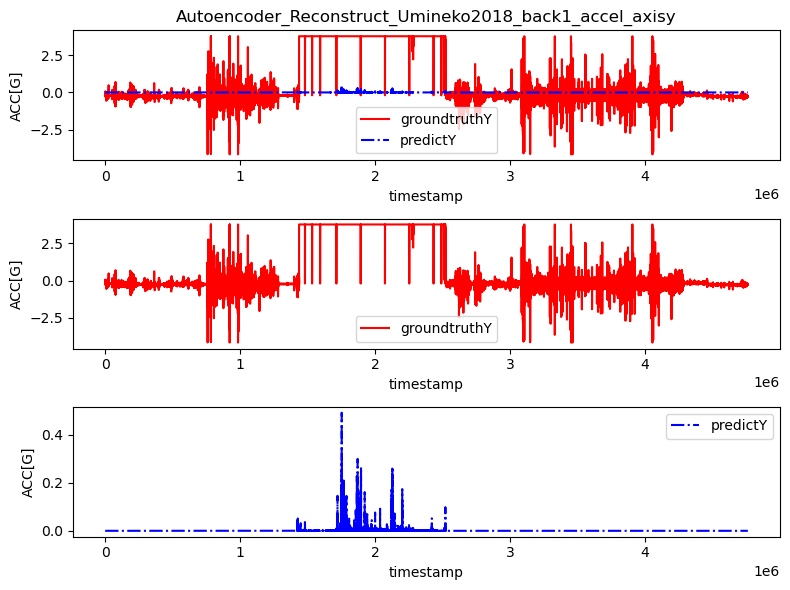

In [29]:

start, end = 1, -1
fig, axes = plt.subplots(3, 1, figsize=(8, 6)) 
axes[0].plot(sample_reshape[start:end, 1], 'r', label='groundtruthY')
axes[0].plot(pred_reshape[start:end, 1], 'b-.', label='predictY')
axes[0].set_title('Autoencoder_Reconstruct_Umineko2018_back1_accel_axisy')
axes[0].set_xlabel('timestamp')
axes[0].set_ylabel('ACC[G]')
axes[0].legend()

axes[1].plot(sample_reshape[start:end, 1], 'r', label='groundtruthY')
# axes[1].plot(pred_reshape[10000:length, 1], 'b-.', label='predictY')
# axes[1].set_title('ResNet_SSL_pretrained_Reconstruct_Umineko2018_back1')
axes[1].set_xlabel('timestamp')
axes[1].set_ylabel('ACC[G]')
axes[1].legend()

# axes[2].plot(sample_reshape[10000:length, 1], 'r', label='groundtruthY')
axes[2].plot(pred_reshape[start:end, 1], 'b-.', label='predictY')
# axes[2].set_title('ResNet_SSL_pretrained_Reconstruct_Umineko2018_back1')
axes[2].set_xlabel('timestamp')
axes[2].set_ylabel('ACC[G]')
axes[2].legend()

# Adjust layout
plt.tight_layout()
# Show the figure
plt.show()

## Training

In [25]:

# training
start_epoch = 0
num_epochs = 1000
lr = 0.0001
training_loss = []
for epoch in tqdm(range(start_epoch, num_epochs)):

    lr = adjust_learning_rate(lr, optimizer, epoch, p_scheduler='cosine', p_epochs=num_epochs)
    
    losses = AE_train_time_series_resnet(train_loader, model, criterion, optimizer, epoch, scheduler, device)
    # if (epoch % 10 == 0) or (epoch == num_epochs-1):
    #     print('loss of the ' + str(epoch) + '-th training epoch is :' + losses.__str__())
    training_loss.append(losses.val)

print('Saving model at: ' + 'Resnet_ssl_pretrain_epoch%s' % str(epoch)\
      + '_datalen%s_' % str(len_sw) + sensor_type + '.pth')
torch.save(model.state_dict(), 'Resnet_ssl_pretrain_epoch%s' % str(epoch) +\
           '_datalen%s_' % str(len_sw) + sensor_type + '.pth')


100%|██████████| 1000/1000 [2:02:13<00:00,  7.33s/it] 

Saving model at: Resnet_ssl_pretrain_epoch999_datalen300_accel.pth


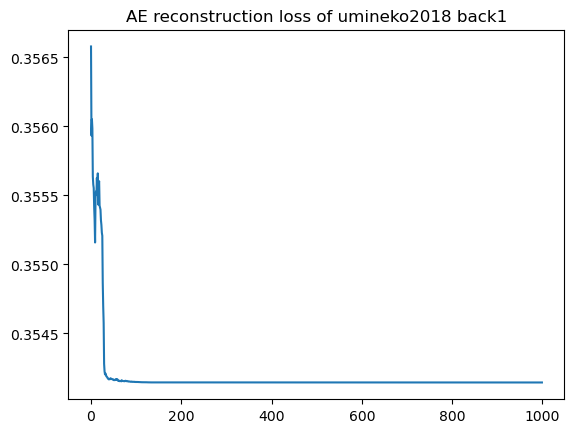

In [26]:
plt.plot(training_loss)
plt.title('AE reconstruction loss of umineko2018 back1')
plt.show()

## visualize reconstructed result (after finuetuned)

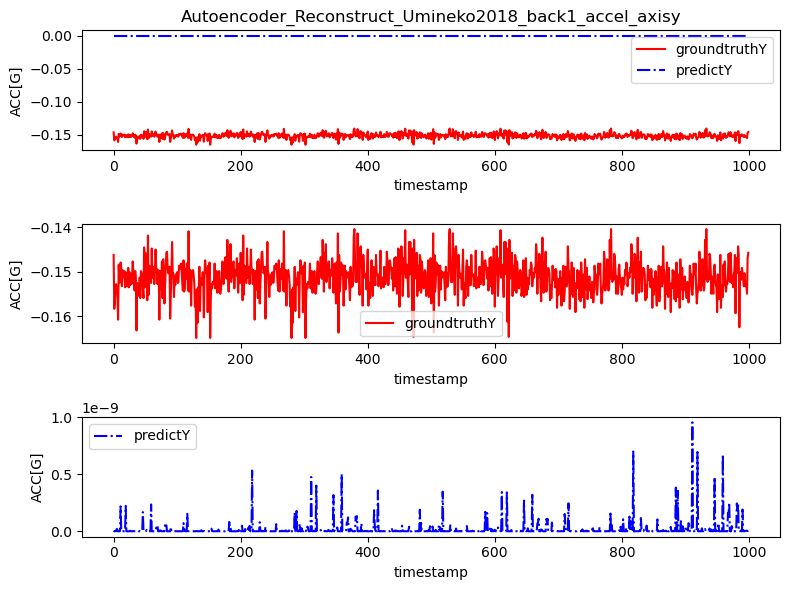

In [27]:
# reconstruction result
representation_list, sample_list, pred_list, label_list = \
            AE_eval_time_series(train_loader, model, device)

# tsne latent representation to shape=(2, len) PCA降维到形状为 (2, len)
repre_concat = np.concatenate(representation_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1)

sample_concat = np.concatenate(sample_list)
# sample_reshape = sample_concat.reshape(-1, 3)
sample_concat = sample_concat.transpose(0,2,1)
sample_reshape = sample_concat.reshape(-1, sample_concat.shape[-1])

pred_concat = np.concatenate(pred_list)
# pred_reshape = pred_concat.reshape(-1, 3)
pred_concat = pred_concat.transpose(0, 2, 1)
pred_reshape = pred_concat.reshape(-1, pred_concat.shape[-1])

label_concat = np.concatenate(label_list)
label_concat_vote = majority_value(label_concat)
# label_concat_vote.shape

start, end = 1000, 2000
fig, axes = plt.subplots(3, 1, figsize=(8, 6)) 
axes[0].plot(sample_reshape[start:end, 1], 'r', label='groundtruthY')
axes[0].plot(pred_reshape[start:end, 1], 'b-.', label='predictY')
axes[0].set_title('Autoencoder_Reconstruct_Umineko2018_back1_accel_axisy')
axes[0].set_xlabel('timestamp')
axes[0].set_ylabel('ACC[G]')
axes[0].legend()

axes[1].plot(sample_reshape[start:end, 1], 'r', label='groundtruthY')
# axes[1].plot(pred_reshape[10000:length, 1], 'b-.', label='predictY')
# axes[1].set_title('ResNet_SSL_pretrained_Reconstruct_Umineko2018_back1')
axes[1].set_xlabel('timestamp')
axes[1].set_ylabel('ACC[G]')
axes[1].legend()

# axes[2].plot(sample_reshape[10000:length, 1], 'r', label='groundtruthY')
axes[2].plot(pred_reshape[start:end, 1], 'b-.', label='predictY')
# axes[2].set_title('ResNet_SSL_pretrained_Reconstruct_Umineko2018_back1')
axes[2].set_xlabel('timestamp')
axes[2].set_ylabel('ACC[G]')
axes[2].legend()

# Adjust layout
plt.tight_layout()
# Show the figure
plt.show()

## feature extraction and visualization via umap

In [28]:

label_concat = np.concatenate(label_list)
label_concat_vote = majority_value(label_concat)
# label_concat_vote.shape

umap_3d = UMAP(n_components=3)

proj_3d_gyro = umap_3d.fit_transform(repre_reshape)

fig_3d = px.scatter_3d(
    proj_3d_gyro, x=0, y=1, z=2,
    color=label_concat_vote.astype(str),  
    labels={'color': 'activity'}
)
fig_3d.update_traces(marker_size=5)

fig_3d.show()

In [14]:
         
# Create a boolean mask for values equal to 1 or 4
mask = (label_concat_vote == 1) | (label_concat_vote == 4)
# Get the indices of the elements that are equal to 1 or 4
indices = np.where(mask)[0]
r = repre_reshape[indices]

l = label_concat_vote[indices]
proj_3d_gyro = umap_3d.fit_transform(r)

fig_3d = px.scatter_3d(
    proj_3d_gyro, x=0, y=1, z=2,
    color=l.astype(str),  
    labels={'color': 'activity'}
)
fig_3d.update_traces(marker_size=5)

fig_3d.show()